# Configs

In [1]:
import random
import numpy as np
import torch
from model_options.cnn_latent import Autoencoder


RANDOM_SEED = 17
COMPRESSION = 16  # 16 is the min compression for the extended simple model, 2^4 times at cnn layers


random.seed(RANDOM_SEED)

np.random.seed(RANDOM_SEED)

torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)


def weightEval(underPerfProba):
    # default weight to reverse of probability
    return 1 - underPerfProba

# Auto encoder

## Read data

In [ ]:
from data_reader.data import listTurbines


turbines = listTurbines()
turbines

In [ ]:
from preprocess.transform_to_3d import TurbineData


turbines = listTurbines()
turbineDatas = [TurbineData(turbine, verbose=False) for turbine in turbines]
commonCols = set(turbineDatas[0].columns).intersection(
    *[turbineData.columns for turbineData in turbineDatas]
)
print(f"Common columns: {sorted(commonCols)}")

Common columns: ['ambienttemperature', 'availablepowerpublished', 'avghumidity', 'avgpitchangle', 'avgpower', 'avgreactivepower', 'avgrotorspeed', 'avgwinddirection', 'avgwindspeed', 'cutoutwindspeed', 'datetime', 'density', 'groundlevelaltitude', 'hubheight', 'latitude', 'longitude', 'nacelleposition', 'normalbehaviour', 'original_feature_count', 'overperformanceprobability', 'overperformanceprobabilitynoisy', 'overperformanceprobabilityvalid', 'ratedwindspeed', 'rotordiameter', 'turbinepressure', 'turbulent', 'turbulentvalid', 'underperformanceprobability', 'underperformanceprobabilitynoisy', 'underperformanceprobabilityvalid', 'windspeedstandarddeviation']


## Split train test

In [4]:
from data_reader.data import getDataRange
from preprocess.normalize import createFeatureTransformer


targetFeatRange = getDataRange()
# targetFeats = ["avgwindspeed"]
targetFeats = list(targetFeatRange.keys())

immuteFeats = [
    "datetime",
    "underperformanceprobability",
    "normalbehaviour",
]

angleFeats = ["avgwinddirection"]  # TODO: ["avgwinddirection"]

rangedFeatRanges = {k: targetFeatRange[k] for k in targetFeats if k not in angleFeats}

transformer = createFeatureTransformer(
    rangedFeatRanges=rangedFeatRanges,
    angleFeats=angleFeats,
    immuteFeats=[],  # immuteFeats are handled below
)

In [ ]:
from preprocess.cls_dataset import toTurbineDatasets
from preprocess.split_data import splitIndices


TEST_RATIO = 0.2
VAL_RATIO = 0.2

trainSets = []
valSets = []
testSets = []

abnormalTestSets = []

for turbineData in turbineDatas:
    print(f"Turbine {turbineData.turbineName}")

    validness = turbineData.evalUnderperformValid(
        maxConsecutiveInvalid=0,  # 1 hours of consecutive invalid data
        maxInvalidRate=0.5,  # 50% of data can be invalid
    )
    print(f"Valid indices: {validness.sum()}")

    normalness = turbineData.evalNormal()
    print(f"Normal indices: {normalness.sum()}")

    normValidIdx = (validness & normalness).nonzero()[0]
    print(f"Normal valid indices: {len(normValidIdx)}")

    trainIndices, valIndices, testIndices = splitIndices(
        normValidIdx,  # use only normal and valid indices for training # type: ignore
        testRatio=TEST_RATIO,
        valRatio=VAL_RATIO,
    )

    # get abnormal valid indices
    abnormalValidIndices = (validness & ~normalness).nonzero()[0]
    abnormTestIndices = list(abnormalValidIndices)
    print(f"Abnormal valid indices: {len(abnormalValidIndices)}")

    trainSet, valSet, testSet, abnSet = toTurbineDatasets(
        turbineData,
        (trainIndices, valIndices, testIndices, abnormTestIndices),
        targetFeats,
        transformer,
        immuteFeats,
    )

    trainSets.append(trainSet)
    valSets.append(valSet)
    testSets.append(testSet)
    abnormalTestSets.append(abnSet)

    print("=" * 50)

## Create data loader

In [6]:
from torch.utils.data import DataLoader

from preprocess.cls_dataset import IMMUTE_GROUP, TARGET_GROUP, TurbineDataset


BATCH_SIZE = 96

# check if trainSets is unbound
try:
    trainSet = TurbineDataset.merge(trainSets)
    valSet = TurbineDataset.merge(valSets)
    testSet = TurbineDataset.merge(testSets)
    abnSet = TurbineDataset.merge(abnormalTestSets)

    # # save the datasets
    # trainSet.save("tmp/full_train_set")
    # valSet.save("tmp/full_val_set")
    # testSet.save("tmp/full_test_set")
    # abnormalTestSet.save("tmp/full_abnormal_test_set")
    # print("Merged and saved datasets successfully.")

except NameError:
    print("The composite dataset is not defined. Try loading the datasets from files.")
    trainSet = TurbineDataset.load("tmp/full_train_set")
    valSet = TurbineDataset.load("tmp/full_val_set")
    testSet = TurbineDataset.load("tmp/full_test_set")
    abnSet = TurbineDataset.load("tmp/full_abnormal_test_set")

print(
    f"Normal/Abnormal ratio: {(len(trainSet) + len(valSet) + len(testSet)) / len(abnSet)}"
)


indexer = trainSet.indexer

trainLoader = DataLoader(trainSet, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
valLoader = DataLoader(valSet, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
testLoader = DataLoader(testSet, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
abnLoader = DataLoader(abnSet, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
abnAndNormLoader = DataLoader(
    TurbineDataset.merge([testSet, abnSet]),
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
)

targetFeats = indexer.getGroupTags(TARGET_GROUP)
print(f"Target features: {targetFeats}")

immuteFeats = indexer.getGroupTags(IMMUTE_GROUP)
print(f"Immute features: {immuteFeats}")

first_batch = next(iter(trainLoader))
inputShape = np.array(first_batch[0].size())
inputShape[0] = len(targetFeats)

# model latent space
n_feat = len(targetFeats)
## reduce the n_feat by n_decompressed feats
sin_feats = [f[:-4] for f in targetFeats if f.endswith("_sin")]  # type: ignore
cos_feats = [f[:-4] for f in targetFeats if f.endswith("_cos")]  # type: ignore
n_decompressed = len(set(sin_feats + cos_feats))

latentSpace = int((n_feat - n_decompressed) * inputShape[1] // COMPRESSION)

print(f"inputShape: {inputShape}")
print(f"latentSpace: {latentSpace}")

Normal/Abnormal ratio: 2.0054113749309774
Target features: ['avgpower', 'avgrotorspeed', 'avgwindspeed', 'density', 'ambienttemperature', 'avgwinddirection_sin', 'avgwinddirection_cos']
Immute features: ['datetime', 'underperformanceprobability', 'normalbehaviour']
inputShape: [ 7 96]
latentSpace: 36


## Validate model

In [7]:
import torch
import torch.nn as nn
from torchinfo import summary

# test if the model is working
testModel = Autoencoder(inputShape, latentSpace)

summary(
    testModel, torch.Size((96, inputShape[0], inputShape[1])), depth=7, device="cpu"
)

Layer (type:depth-idx)                             Output Shape              Param #
Autoencoder                                        [96, 7, 96]               --
├─Sequential: 1-1                                  [96, 2, 12]               --
│    └─Encoder: 2-1                                [96, 4, 48]               --
│    │    └─Sequential: 3-1                        [96, 16, 48]              --
│    │    │    └─Sequential: 4-1                   [96, 16, 48]              --
│    │    │    │    └─Conv1d: 5-1                  [96, 16, 96]              352
│    │    │    │    └─ReLU: 5-2                    [96, 16, 96]              --
│    │    │    │    └─AvgPool1d: 5-3               [96, 16, 48]              --
│    │    └─Conv1d: 3-2                            [96, 4, 48]               196
│    └─Encoder: 2-2                                [96, 4, 24]               --
│    │    └─Sequential: 3-3                        [96, 32, 24]              --
│    │    │    └─Sequential: 4-2 

## Training 

### Train Injections

In [8]:
def inferBatch(batch, model):

    # reshapre to (batch, feats as channels, timesteps)
    imm = indexer.slice(batch, immuteFeats, dim=1)
    inp = indexer.slice(batch, targetFeats, dim=1)

    out = model(inp)

    return torch.cat((out, imm), dim=1), torch.cat((inp, imm), dim=1)

In [9]:
def weightCal(pred, actual):
    underPerfProba = indexer.slice(pred, ["underperformanceprobability"], dim=1)
    underPerfProba = torch.nan_to_num(underPerfProba, nan=0.0, posinf=1, neginf=0.0)
    underPerfProba = torch.clamp(underPerfProba, min=0.0, max=1.0)
    weight = weightEval(underPerfProba)

    return weight

### Loop

In [10]:
import datetime
from matplotlib import pyplot as plt
import torch.optim as optim

from train.loss import TargetedLoss, SampleWeightedLoss
from train.trainer import infer, trainLayerByLayer


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


model = Autoencoder(inputShape, latentSpace)

# use mean average error
rawLoss = nn.MSELoss(reduction="none")
targetedLoss = TargetedLoss(rawLoss, indexer.getIdx(targetFeats))
criterion = SampleWeightedLoss(
    targetedLoss,
    weightCal=weightCal,
)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 100
earlyStopping = 10

trainLosses = []
valLosses = []


def abnormLossCal():
    pred, actual = infer(model, device, abnLoader, inferBatch=inferBatch)
    return criterion(pred, actual)


model, trainLosses, valLosses, info = trainLayerByLayer(
    model,
    device,
    trainLoader,
    valLoader,
    criterion,
    optimizer,
    epochsPerLayer=num_epochs,
    earlyStopping=earlyStopping,
    inferBatch=inferBatch,
    verbose=False,
    trackVars={
        "abnormalLoss": abnormLossCal,
    },
)
# save model
torch.save(
    model.state_dict(),
    f"output/simple_extended_model_{datetime.datetime.now().strftime('%M:%H_%m-%d')}.pth",
)

Device: cuda


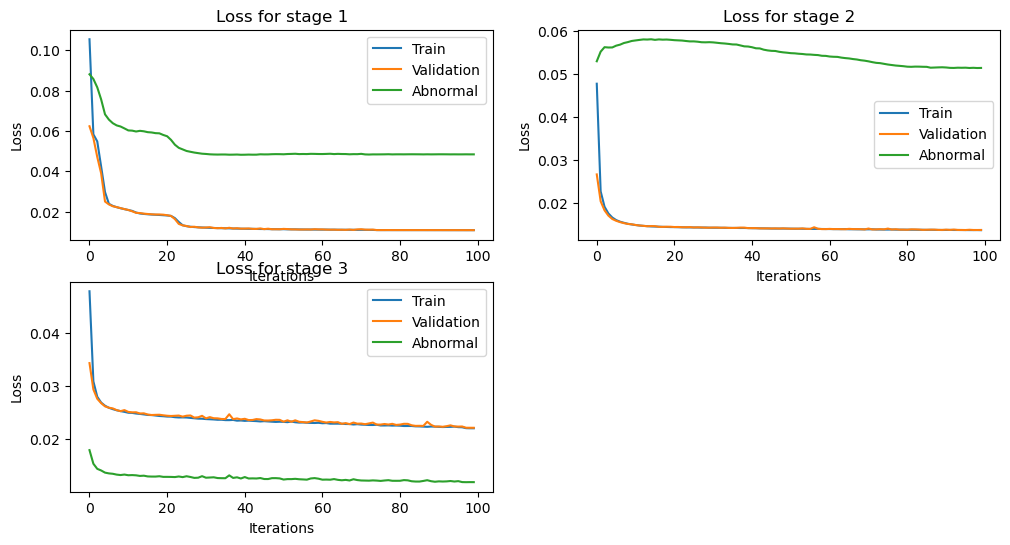

In [11]:
# plt.xlabel("Iterations")
# plt.ylabel("Loss")

# abnLoss = info["abnormalLoss"]
# abnLoss = [i.item() for i in abnLoss]

# plt.plot(trainLosses[:])
# plt.plot(valLosses[:])
# plt.plot(abnLoss[:])

# # plt.ylim(-0, 0.01)

# plt.legend(["Train", "Validation", "Abnormal"])
# plt.show()

plt.figure(figsize=(12, 6))
for i in range(len(trainLosses)):
    plt.subplot(len(trainLosses) // 2 + 1, 2, i + 1)
    plt.plot(trainLosses[i][:], label="Train")
    plt.plot(valLosses[i][:], label="Validation")

    abnLoss = info[i]["abnormalLoss"]
    abnLoss = [i.item() for i in abnLoss]
    plt.plot(abnLoss[:], label="Abnormal")
    plt.title(f"Loss for stage {i + 1}")
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.legend()
plt.show()

## Evaluating

### MAE

In [12]:
from preprocess.normalize import decodeAngles
from train.trainer import infer


normOutputs, normActuals = infer(model, device, testLoader, inferBatch)

circularFeats = ["avgwinddirection"]
skipFeats = []
errs = []
for feat in targetFeats:
    if feat in skipFeats:
        continue

    assert isinstance(feat, str), f"Feature {feat} is not a string"
    featIndex = indexer[feat]
    print(f"Feature {feat} :")

    if feat in circularFeats:
        featErr = torch.sub(
            normOutputs[:, featIndex : (featIndex + 1), :],
            normActuals[:, featIndex : (featIndex + 1), :],
        )
        featErr = torch.where(
            featErr > 0.5,
            featErr - 1,
            torch.where(featErr < -0.5, featErr + 1, featErr),
        )

    elif feat.endswith("_sin") or feat.endswith("_cos"):
        print(f"Feature {feat[:-4]} :")

        sinFeat = feat[:-4] + "_sin"
        cosFeat = feat[:-4] + "_cos"
        skipFeats.append(sinFeat)
        skipFeats.append(cosFeat)

        sinIndex = indexer[sinFeat]
        cosIndex = indexer[cosFeat]

        # transform sin and cos data to n * time_steps, 2
        sinRec = normOutputs[:, sinIndex : (sinIndex + 1), :].reshape(-1, 1)
        cosRec = normOutputs[:, cosIndex : (cosIndex + 1), :].reshape(-1, 1)

        sinOrg = normActuals[:, sinIndex : (sinIndex + 1), :].reshape(-1, 1)
        cosOrg = normActuals[:, cosIndex : (cosIndex + 1), :].reshape(-1, 1)

        angleRec = torch.cat((sinRec, cosRec), dim=1)
        angleOrg = torch.cat((sinOrg, cosOrg), dim=1)

        # run through decodeAngles (n * time_steps, 1)
        angleRec = decodeAngles(angleRec.cpu().numpy())
        angleOrg = decodeAngles(angleOrg.cpu().numpy())

        # transform back to n, 1, time_steps
        angleRec = angleRec.reshape(normOutputs.size(0), 1, normOutputs.size(2))
        angleOrg = angleOrg.reshape(normActuals.size(0), 1, normActuals.size(2))

        # calculate error like in circular feats but for 360 instead of 1
        featErr = angleRec - angleOrg
        featErr = (
            np.where(
                featErr > 180,
                featErr - 360,
                np.where(featErr < -180, featErr + 360, featErr),
            )
            / 360.0
        )
        featErr = torch.tensor(featErr, device=device)
    else:
        featErr = torch.sub(
            normOutputs[:, featIndex : (featIndex + 1), :],
            normActuals[:, featIndex : (featIndex + 1), :],
        )

    errs.append(featErr)

    print(f"\tMean: {featErr.mean().item()}")
    print(f"\tStd: {featErr.std().item()}")
    print(f"\tMax: {featErr.max().item()}")
    print(f"\tMin: {featErr.min().item()}")
    print(f"\tMean abs: {featErr.abs().mean().item()}")

errs = torch.stack(errs, dim=1)
print(f"Test MAE: {errs.abs().mean().mean().item()}")

Feature avgpower :
	Mean: -0.0013962475350126624
	Std: 0.10694552212953568
	Max: 0.748393714427948
	Min: -0.753735363483429
	Mean abs: 0.07713174819946289
Feature avgrotorspeed :
	Mean: -0.0018201360944658518
	Std: 0.0745449811220169
	Max: 0.7014018893241882
	Min: -0.38101762533187866
	Mean abs: 0.05311094969511032
Feature avgwindspeed :
	Mean: -0.00021065230248495936
	Std: 0.03683310002088547
	Max: 0.25318458676338196
	Min: -0.3108472228050232
	Mean abs: 0.028103778138756752
Feature density :
	Mean: 0.005724461283534765
	Std: 0.026477623730897903
	Max: 0.15877890586853027
	Min: -0.11812657117843628
	Mean abs: 0.01720903255045414
Feature ambienttemperature :
	Mean: -0.0015916392439976335
	Std: 0.07415307313203812
	Max: 0.5467712879180908
	Min: -0.4785310626029968
	Mean abs: 0.05485830828547478
Feature avgwinddirection_sin :
Feature avgwinddirection :
	Mean: 9.483095345785841e-05
	Std: 0.04576742649078369
	Max: 0.49965107440948486
	Min: -0.49984288215637207
	Mean abs: 0.0247567929327487

### Other metrics

In [13]:
org = indexer.slice(normActuals, targetFeats, dim=1)
reconst = indexer.slice(normOutputs, targetFeats, dim=1)

#### Peak Signal-to-Noise Ratio

In [14]:
MAX_PIXEL = 1

mse = torch.mean((org - reconst) ** 2).item()  # type: ignore
psnr = 10 * np.log10(MAX_PIXEL / mse)
print(f"PSNR: {psnr:.4f} dB")

PSNR: 22.4263 dB


#### Maximum Mean Discrepancy

In [15]:
from torch.utils.data import TensorDataset
from ignite.engine import Engine
from ignite.metrics import MaximumMeanDiscrepancy


def compute_mmd(x, y, sigma=1.0):
    dset = TensorDataset(x, y)
    loader = DataLoader(dset, batch_size=BATCH_SIZE, shuffle=False)

    def eval_f(engine, batch):
        return batch

    eval_tor = Engine(eval_f)

    mmd = MaximumMeanDiscrepancy()
    mmd.attach(eval_tor, "mmd")

    state = eval_tor.run(loader)

    return state.metrics["mmd"]


compute_mmd(reconst, org)

/home/tu/micromamba/envs/nbm/lib/python3.12/site-packages/ignite/handlers/checkpoint.py:16: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import ZeroRedundancyOptimizer


0.0

#### Wasserstein

In [16]:
from scipy.stats import wasserstein_distance


def compute_wasserstein(x, y):
    x_flat = x.reshape(x.shape[0], -1)
    y_flat = y.reshape(y.shape[0], -1)
    dists = [
        wasserstein_distance(x_flat[:, i], y_flat[:, i]) for i in range(x_flat.shape[1])
    ]
    return np.mean(dists)


compute_wasserstein(org.cpu().numpy(), reconst.cpu().numpy())

np.float64(0.0126656453553326)

#### t-NSE

In [17]:
from sklearn.manifold import TSNE


def plot_tsne(z, labels=None, title="Latent t-SNE"):
    tsne = TSNE(n_components=2, perplexity=30, random_state=0)
    z_2d = tsne.fit_transform(z)
    plt.figure(figsize=(6, 5))
    if labels is not None:
        plt.scatter(z_2d[:, 0], z_2d[:, 1], c=labels, cmap="tab10", s=10)
    else:
        plt.scatter(z_2d[:, 0], z_2d[:, 1], s=10)
    plt.title(title)
    plt.show()


def inferBatchEnc(batch, model):

    # reshapre to (batch, feats as channels, timesteps)
    imm = indexer.slice(batch, immuteFeats, dim=1)
    inp = indexer.slice(batch, targetFeats, dim=1)

    out = model(inp)

    return out, torch.cat((inp, imm), dim=1)  # type: ignore


encoded, _ = infer(model.encoders, device, testLoader, inferBatchEnc)
encoded = torch.tanh(encoded)  # add encoder activation
z = encoded.detach().cpu().numpy()
# plot_tsne(z)

## Reconstruct graph

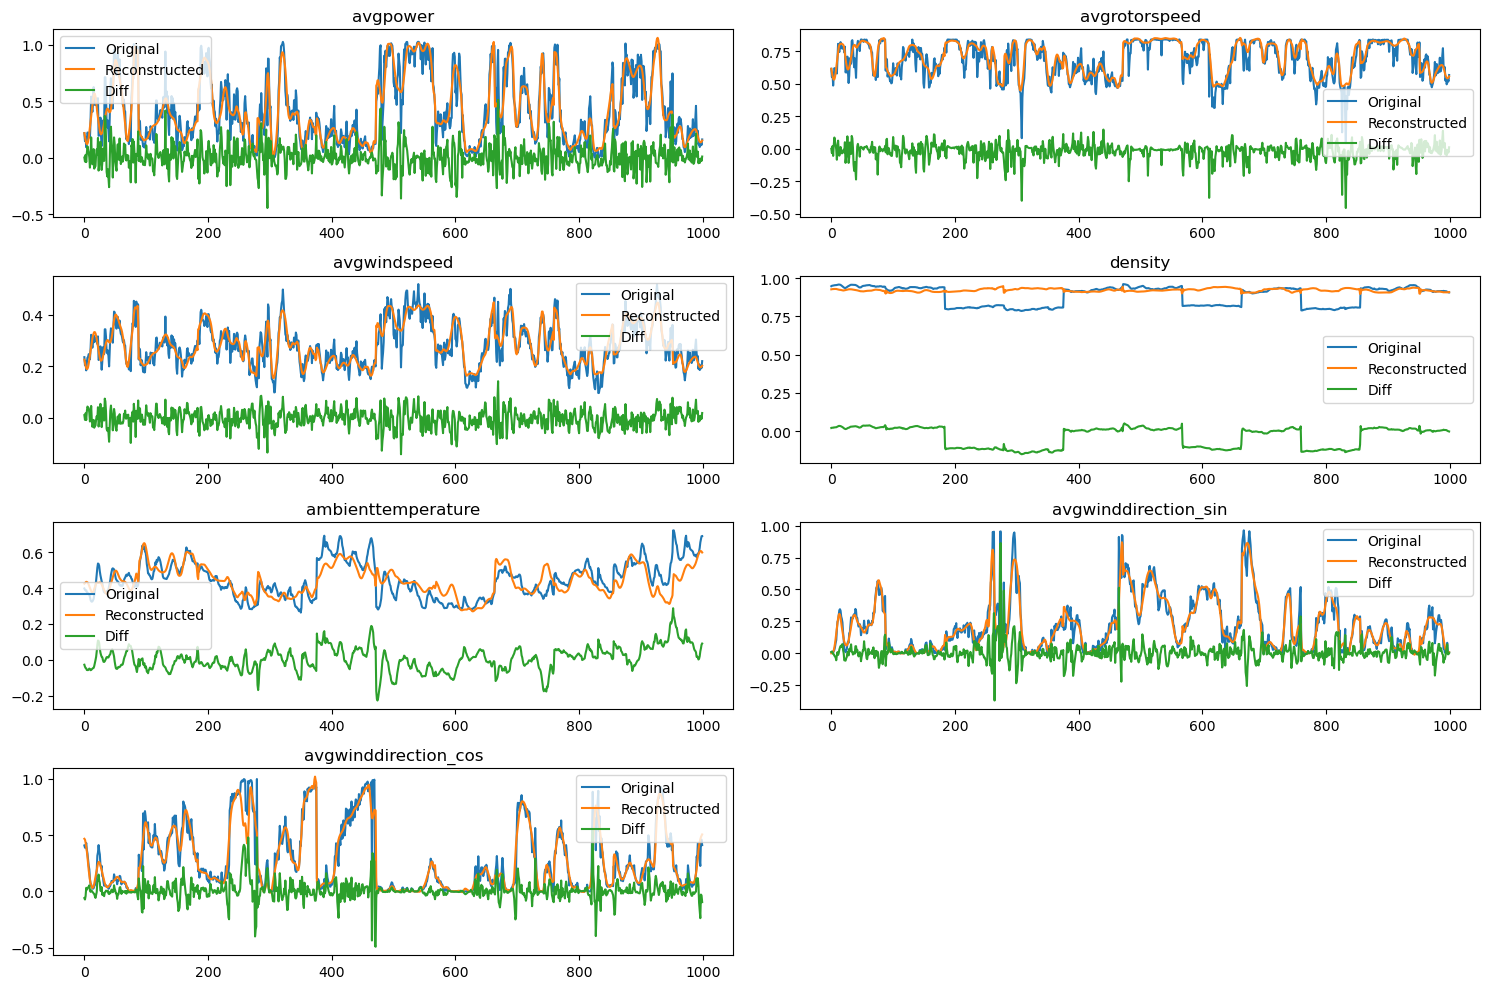

In [18]:
a = 5000
b = a + 1000

plt.figure(figsize=(15, 10))
for i, feat in enumerate(targetFeats):
    featIdx = indexer[feat]
    org = normActuals[:, featIdx, :].detach().cpu().numpy().reshape(-1)
    reconst = normOutputs[:, featIdx, :].detach().cpu().numpy().reshape(-1)

    plt.subplot(len(targetFeats) // 2 + 1, 2, i + 1)
    plt.plot(org[a:b], label="Original")
    plt.plot(reconst[a:b], label="Reconstructed")
    plt.plot(org[a:b] - reconst[a:b], label="Diff")
    plt.legend()
    plt.title(str(feat))
plt.tight_layout()
plt.show()

In [19]:
plt.figure(figsize=(15, 10))
for i, feat in enumerate(targetFeats):
    featIdx = indexer[feat]
    org = normActuals[:, featIdx, :].detach().cpu().numpy().reshape(-1)
    reconst = normOutputs[:, featIdx, :].detach().cpu().numpy().reshape(-1)

    plt.subplot(len(targetFeats), 1, i + 1)
    plt.plot(org, label="Original")
    plt.plot(reconst, label="Reconstructed")
    plt.plot(org - reconst, label="Diff")
    plt.legend()
    plt.title(str(feat))
plt.tight_layout()
plt.savefig("output/target_feats.svg")
plt.close()

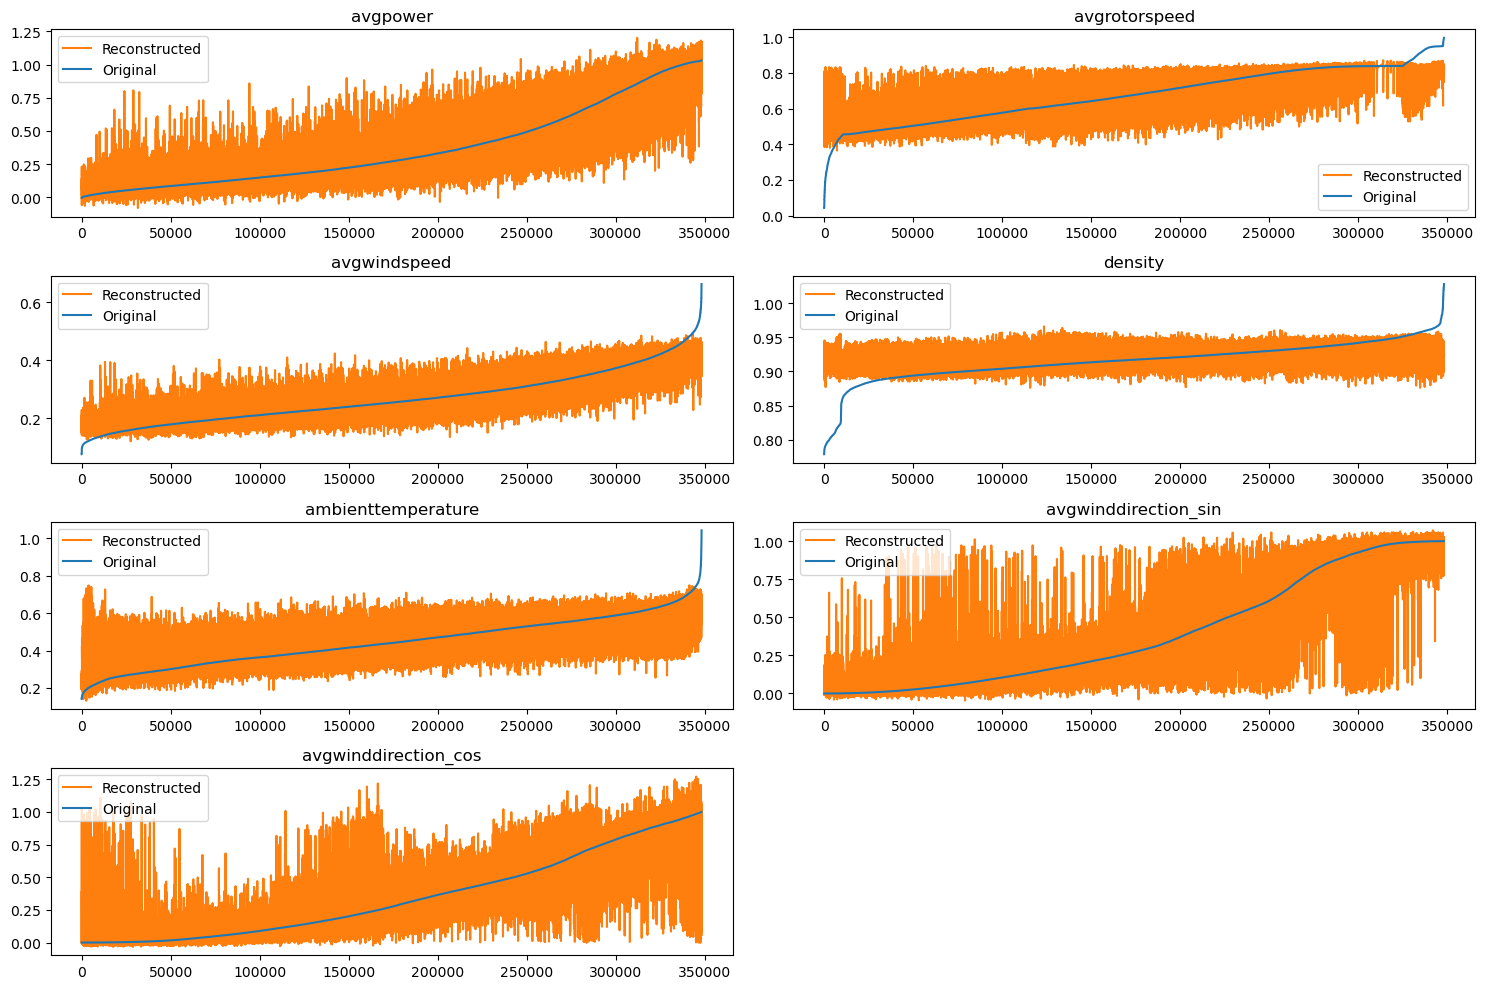

In [20]:
# plot for all targetFeats
plt.figure(figsize=(15, 10))
for i, feat in enumerate(targetFeats):
    featIdx = indexer[feat]
    org = normActuals[:, featIdx, :].detach().cpu().numpy().reshape(-1)
    reconst = normOutputs[:, featIdx, :].detach().cpu().numpy().reshape(-1)

    sortedOrg, sortedReconst = zip(*sorted(zip(org, reconst)))

    plt.subplot(len(targetFeats) // 2 + 1, 2, i + 1)
    plt.plot(sortedReconst, label="Reconstructed", color="#ff7f0e")
    plt.plot(sortedOrg, label="Original", color="#1f77b4")
    plt.title(str(feat))
    plt.legend()
plt.tight_layout()
plt.show()

## [scatter] Real vs. predicted

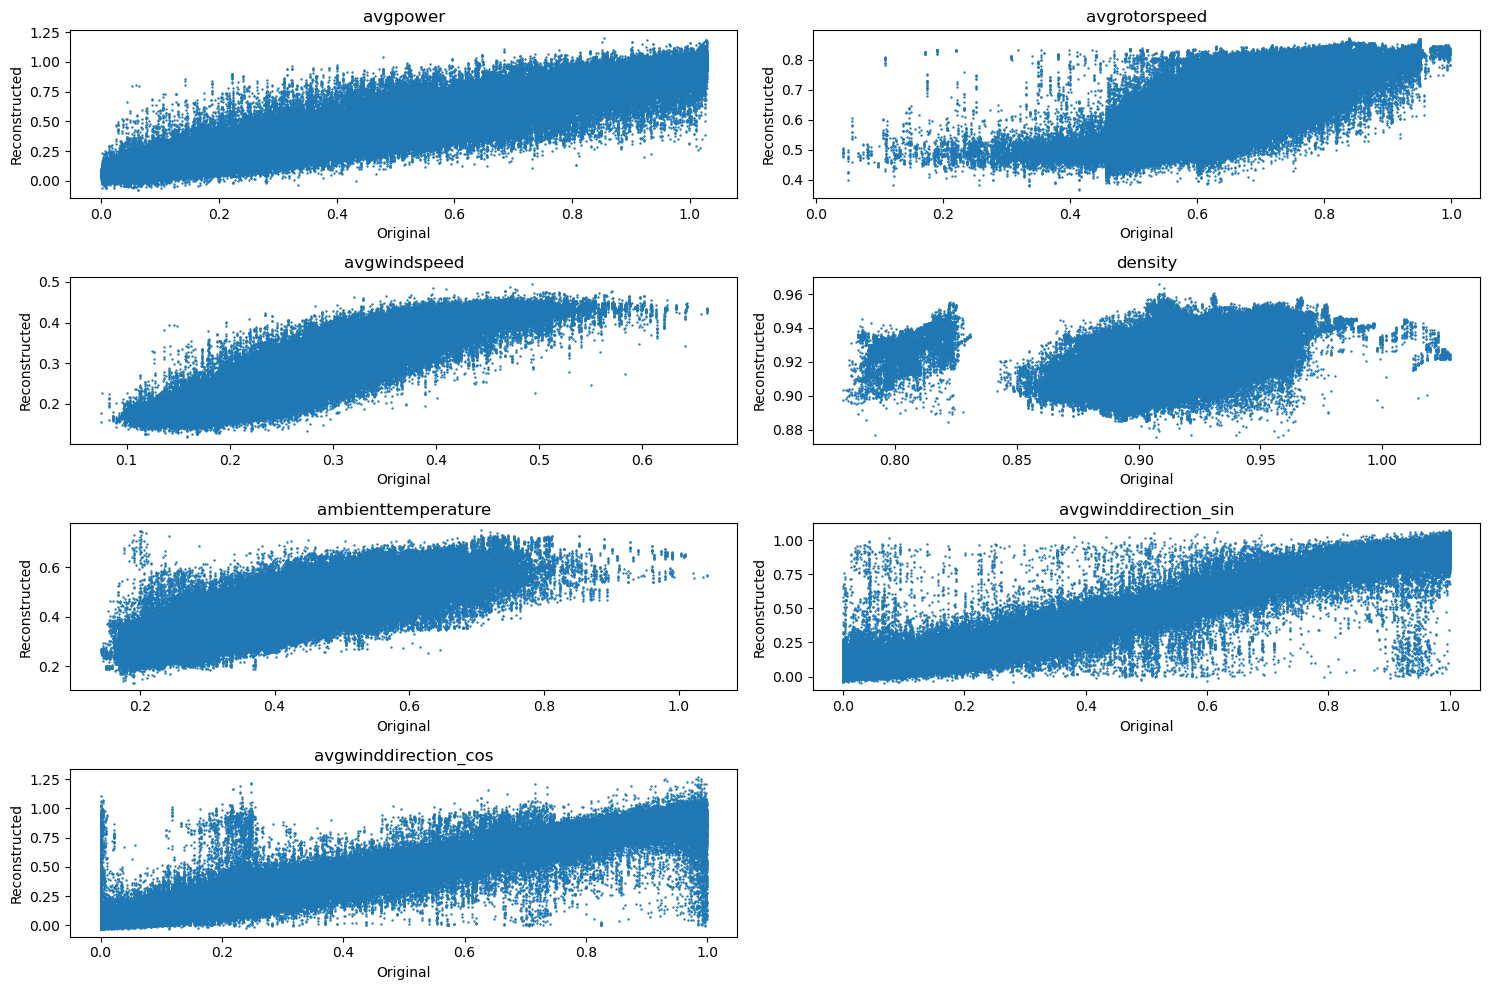

In [21]:
# scatter plot of real vs predicted for all targetFeats
plt.figure(figsize=(15, 10))
for i, feat in enumerate(targetFeats):
    featIdx = indexer[feat]
    org = normActuals[:, featIdx, :].detach().cpu().numpy().reshape(-1)
    reconst = normOutputs[:, featIdx, :].detach().cpu().numpy().reshape(-1)

    plt.subplot(len(targetFeats) // 2 + 1, 2, i + 1)
    plt.scatter(org, reconst, s=0.5)
    plt.xlabel("Original")
    plt.ylabel("Reconstructed")
    plt.title(str(feat))
plt.tight_layout()
plt.show()

## [line] Error (either MAE or MSE) through time (aggregate weekly or monthly to ease visualization)

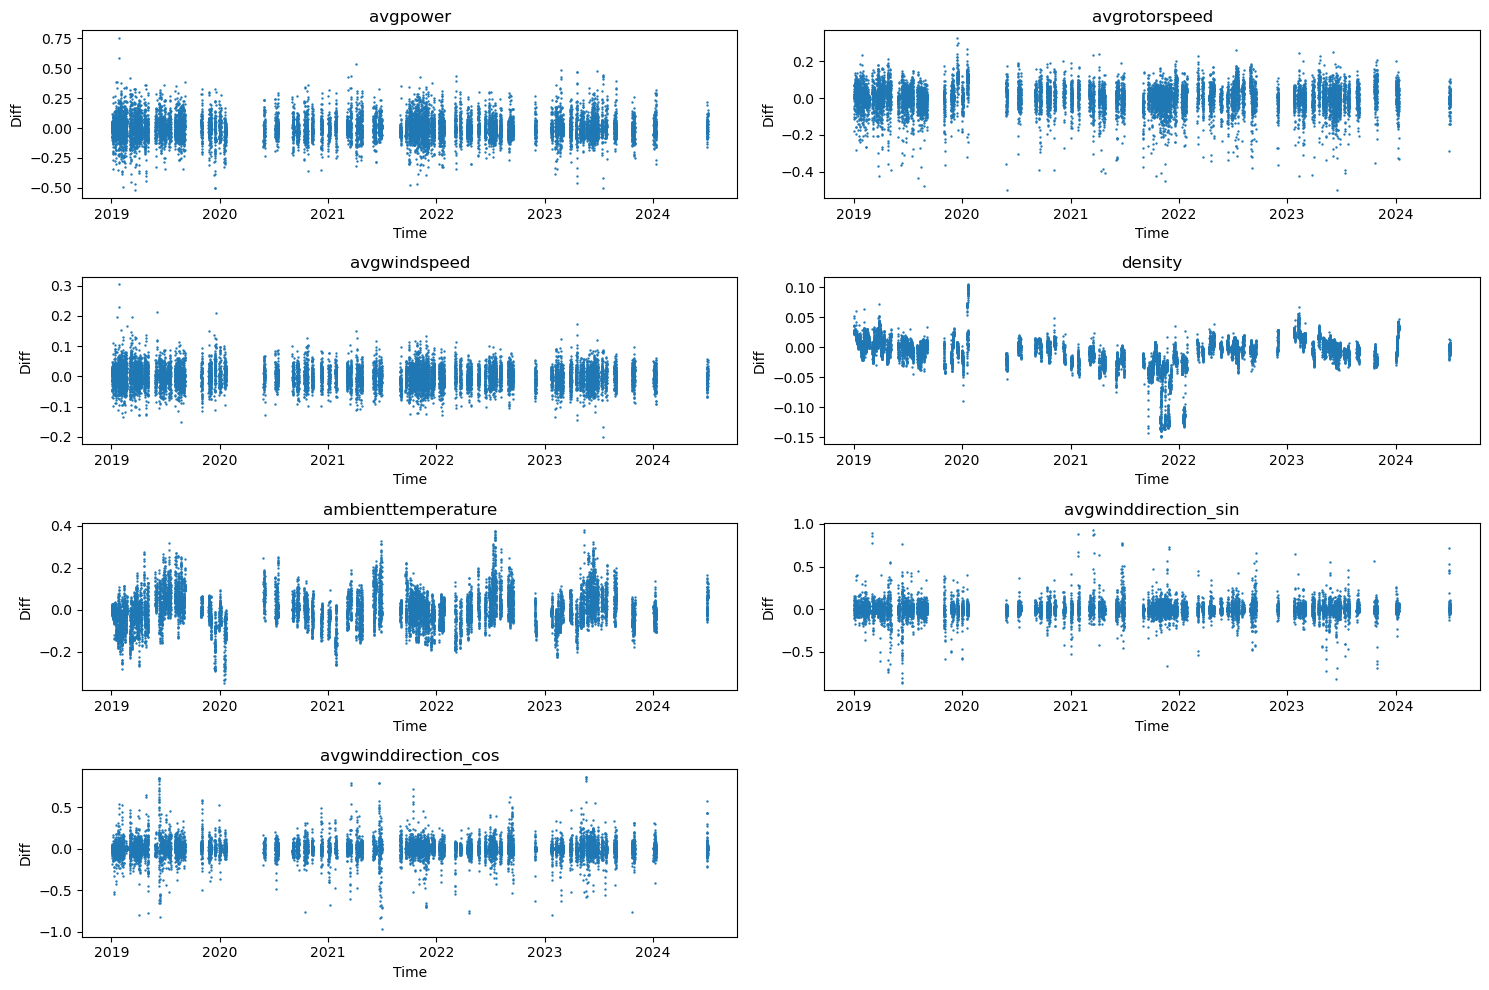

In [22]:
import datetime


timeFeat = normActuals[:, indexer["datetime"], :].detach().cpu().numpy().reshape(-1)

plt.figure(figsize=(15, 10))
for i, feat in enumerate(targetFeats):
    featIdx = indexer[feat]
    org = normActuals[:, featIdx, :].detach().cpu().numpy().reshape(-1)
    reconst = normOutputs[:, featIdx, :].detach().cpu().numpy().reshape(-1)

    diff = org - reconst

    sortedTime, diffByTime = zip(*sorted(zip(timeFeat, diff)))

    map = {}
    unkTime = 0
    for value, time in zip(diffByTime, sortedTime):
        try:
            time = datetime.datetime.fromtimestamp(float(time))
        except ValueError:
            unkTime += 1
            continue

        if time not in map:
            map[time] = (value, 1)
        else:
            map[time] = (map[time][0] + value, map[time][1] + 1)

    diffByTime = [value / count for value, count in map.values()]
    timeUniq = list(map.keys())

    plt.subplot(len(targetFeats) // 2 + 1, 2, i + 1)
    plt.scatter(timeUniq, diffByTime, s=0.5)
    plt.title(str(feat))
    plt.xlabel("Time")
    plt.ylabel("Diff")
plt.tight_layout()
plt.show()

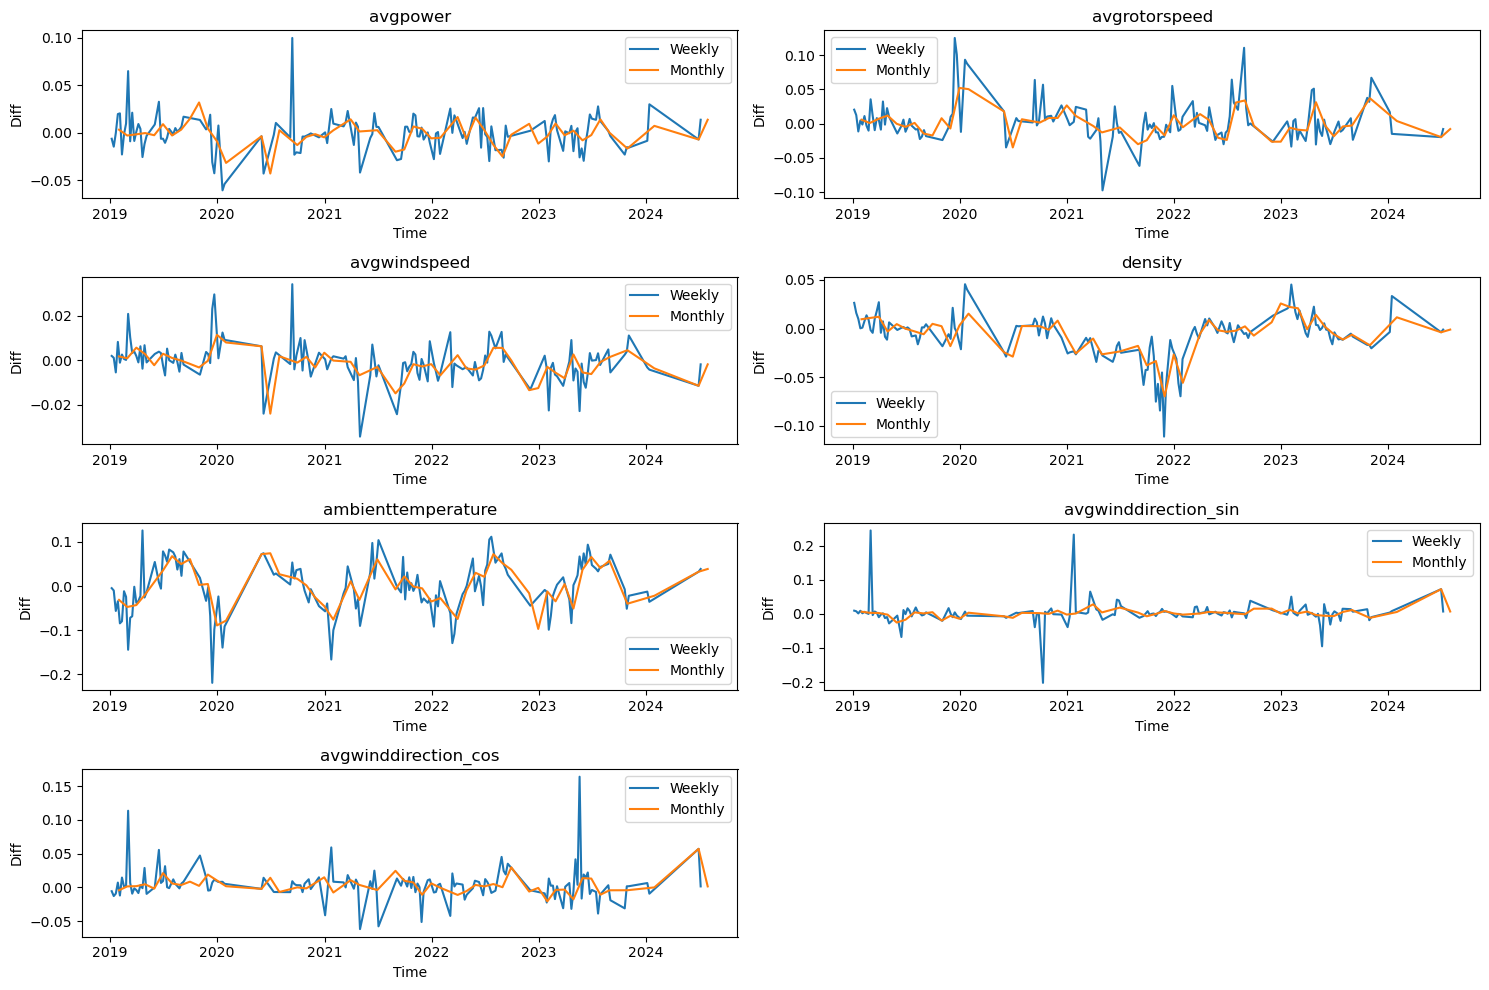

In [23]:
import pandas as pd


timeFeat = normActuals[:, indexer["datetime"], :].detach().cpu().numpy().reshape(-1)

plt.figure(figsize=(15, 10))
for i, feat in enumerate(targetFeats):
    featIdx = indexer[feat]
    org = normActuals[:, featIdx, :].detach().cpu().numpy().reshape(-1)
    reconst = normOutputs[:, featIdx, :].detach().cpu().numpy().reshape(-1)

    diff = org - reconst

    sortedTime, diffByTime = zip(*sorted(zip(timeFeat, diff)))

    map = {}
    unkTime = 0
    for value, time in zip(diffByTime, sortedTime):
        try:
            time = datetime.datetime.fromtimestamp(float(time))
        except ValueError:
            unkTime += 1
            continue

        if time not in map:
            map[time] = (value, 1)
        else:
            map[time] = (map[time][0] + value, map[time][1] + 1)

    diffByTime = [value / count for value, count in map.values()]
    timeUniq = list(map.keys())

    dfDiff = pd.DataFrame({"time": timeUniq, "diff": diffByTime})
    dfDiff.set_index("time", inplace=True)

    dfWeek = dfDiff.resample("W").mean()
    dfWeek.dropna(inplace=True)

    dfMonth = dfDiff.resample("ME").mean()
    dfMonth.dropna(inplace=True)

    plt.subplot(len(targetFeats) // 2 + 1, 2, i + 1)
    plt.plot(dfWeek.index, dfWeek["diff"], label="Weekly")
    plt.plot(dfMonth.index, dfMonth["diff"], label="Monthly")
    plt.title(str(feat))
    plt.xlabel("Time")
    plt.ylabel("Diff")
    plt.legend()
plt.tight_layout()
plt.show()

## [scatter] Error vs. underperformance probability

In [24]:
# org = actual[:, featIdx].detach().cpu().numpy().reshape(-1)
# reconst = outputs[:, featIdx].detach().cpu().numpy().reshape(-1)
# diff = org - reconst

# underProba = (
#     actual[:, indexer["underperformanceprobability"]].detach().cpu().numpy().reshape(-1)
# )

# plt.figure(figsize=(10, 5))
# plt.scatter(underProba, diff **2, s=0.5)
# plt.xlabel("Underperformance probability")
# plt.ylabel("Diff")
# plt.title(f"{featName} diff vs underperformance probability")
# plt.savefig("output/diff_vs_underperformance.pdf")
# plt.show()

In [25]:
# ### Average diff by underperformance probability
# df = pd.DataFrame({"underProba": underProba, "diff": np.abs(diff)})

# num_bins = 20
# df["binned"] = pd.cut(df["underProba"], bins=num_bins)

# grouped = df.groupby("binned")["diff"]

# box_data = [group for _, group in grouped]

# # Create boxplot
# plt.figure(figsize=(12, 6))
# plt.boxplot(box_data, showmeans=True)

# # Label x-axis with bin ranges
# bin_labels = [
#     f"{interval.left:.2f}-{interval.right:.2f}" for interval in grouped.groups.keys()
# ]
# plt.xticks(ticks=np.arange(1, len(bin_labels) + 1), labels=bin_labels, rotation=45)

# plt.xlabel("Underperformance Probability (binned)")
# plt.ylabel("Diff")
# plt.title(f"{featName} diff vs underperformance probability (box plot)")
# plt.tight_layout()
# plt.show()

# Abnormal Detection

In [26]:
recons, normActuals = infer(model.getStage(1), device, abnAndNormLoader, inferBatch)

orgFeat = indexer.slice(normActuals, targetFeats, dim=1)
reconsFeat = indexer.slice(recons, targetFeats, dim=1)
reconsError = torch.abs(orgFeat - reconsFeat)

timeFlag = indexer.slice(normActuals, ["datetime"], dim=1)
normalFlag = indexer.slice(normActuals, ["normalbehaviour"], dim=1)

dayErr = []
dayNormal = []
for i0 in range(reconsError.size(0)):
    for i2 in range(reconsError.size(2) - 23):
        dt = datetime.datetime.fromtimestamp(timeFlag[i0, 0, i2].cpu().item())
        hour = dt.hour
        minute = dt.minute
        if (hour == 23 and minute >= 1) or (hour == 0 and minute <= 59):
            # if the time is between 23:01 and 00:59, collect the whole day (24 steps)
            sample = reconsError[i0, :, i2 : i2 + 24]
            dayErr.append(sample.tolist())

            normalCount = normalFlag[i0, :, i2 : i2 + 24].bool().sum().item()

            if normalCount <= 2:
                aproxNormal = False
            elif normalCount >= 22:
                aproxNormal = True
            else:
                raise ValueError(
                    f"Unexpected normal count {normalCount} for turbine {i0} at time {dt}"
                )

            dayNormal.append(aproxNormal)
            i2 += 23  # skip the next 23 steps, as we already processed them
dayErr = np.array(dayErr)
dayNormal = np.array(dayNormal)

print(f"Shape of dayErr: {dayErr.shape}")
print(f"Shape of dayNormal: {dayNormal.shape}")

Shape of dayErr: (53386, 7, 24)
Shape of dayNormal: (53386,)


In [27]:
# auc for each feature, using std
from sklearn.metrics import roc_auc_score

for i in range(dayErr.shape[1]):
    feature_errors = dayErr[:, i]
    auc = roc_auc_score(dayNormal, feature_errors.max(axis=1))
    print(f"Feature {targetFeats[i]}: AUC = {auc:.4f}")

Feature avgpower: AUC = 0.5401
Feature avgrotorspeed: AUC = 0.4547
Feature avgwindspeed: AUC = 0.5629
Feature density: AUC = 0.5220
Feature ambienttemperature: AUC = 0.5086
Feature avgwinddirection_sin: AUC = 0.5077
Feature avgwinddirection_cos: AUC = 0.5276


In [28]:
# cal the auc for the dayErr and dayNormal
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    dayNormal, 1 - dayErr.max(axis=2).mean(axis=1)
)  # max per feature, mean per day
print(f"AUC for day error and normal flag: {auc:.4f}")

AUC for day error and normal flag: 0.4730


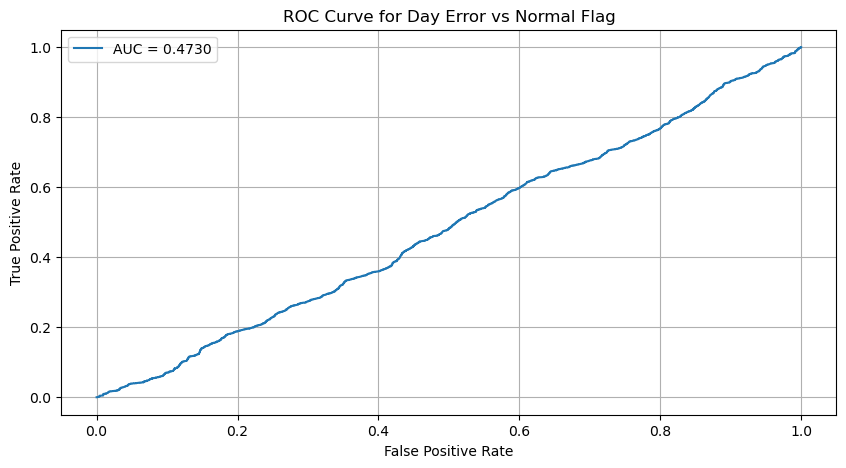

In [29]:
# visualize roc curve
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(dayNormal, 1 - dayErr.mean(axis=2).mean(axis=1))
plt.figure(figsize=(10, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Day Error vs Normal Flag")
plt.legend()
plt.grid()
plt.show()

### Err histogram

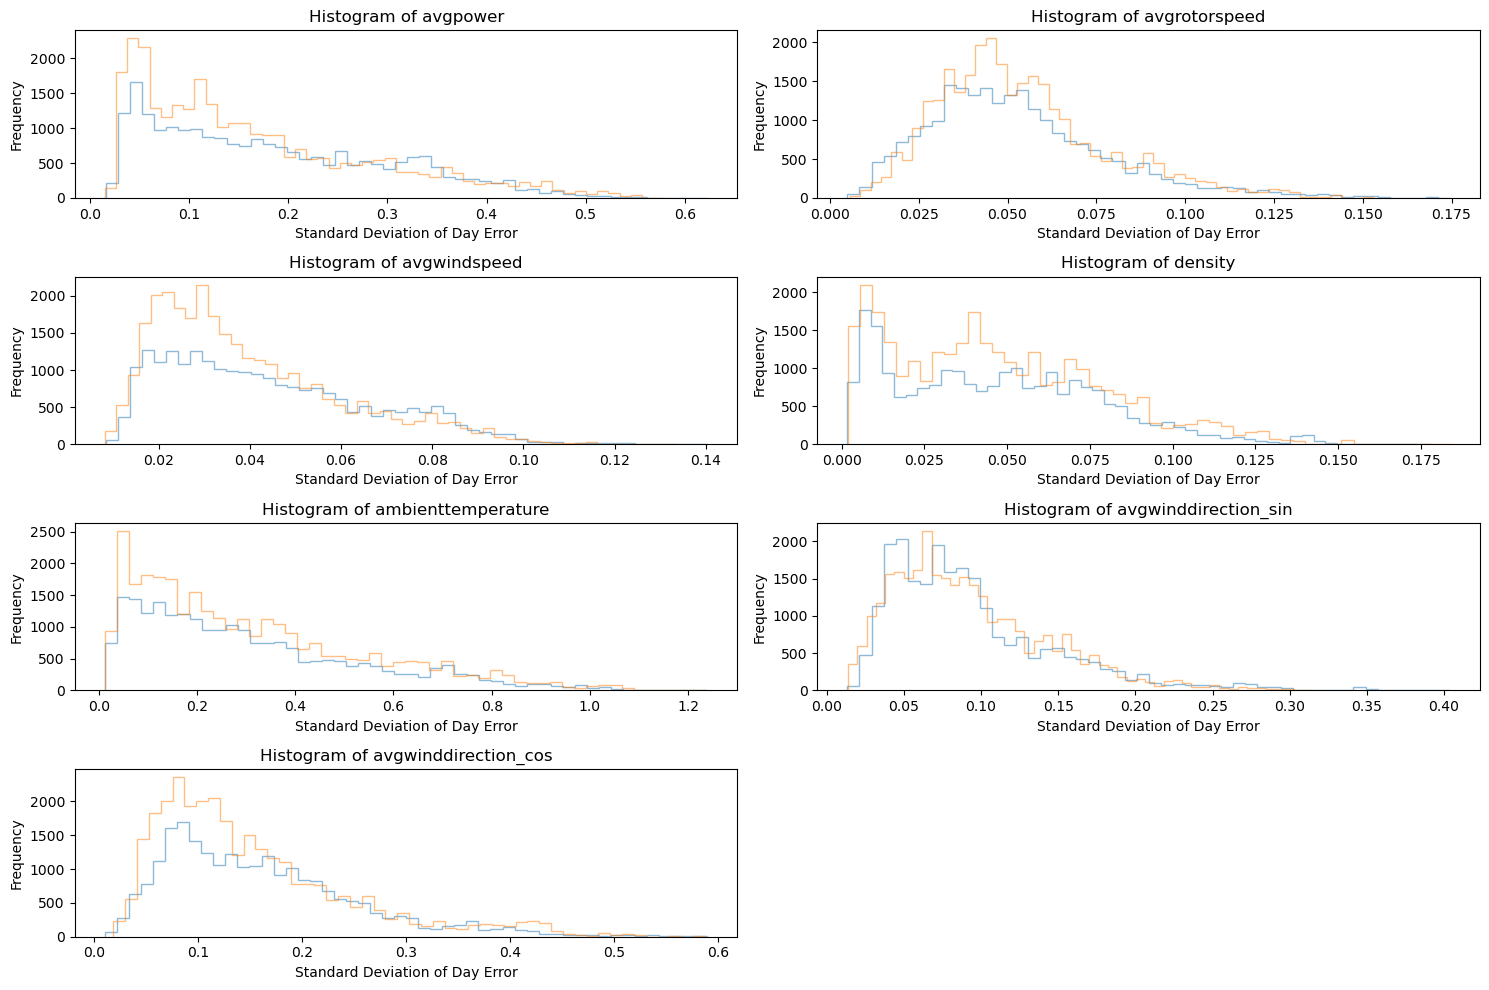

In [30]:
plt.figure(figsize=(15, 10))
for i in range(dayErr.shape[1]):
    featDayErr = dayErr[:, i]  # (sample, timestep)
    # slice err to normal and abnormal days; dayNormal - (sample)
    normalDays = featDayErr[dayNormal, :]
    abnormalDays = featDayErr[~dayNormal, :]

    plt.subplot(len(targetFeats) // 2 + 1, 2, i + 1)

    plt.hist(
        normalDays.std(axis=1),
        bins=50,
        alpha=0.5,
        histtype="step",
        label="Normal Days",
    )
    plt.hist(
        abnormalDays.std(axis=1),
        bins=50,
        alpha=0.5,
        histtype="step",
        label="Abnormal Days",
    )

    plt.xlabel("Standard Deviation of Day Error")
    plt.ylabel("Frequency")
    plt.title(f"Histogram of {targetFeats[i]}")
plt.tight_layout()
plt.show()

## AU-PR

AUPR: 0.43687231773419566


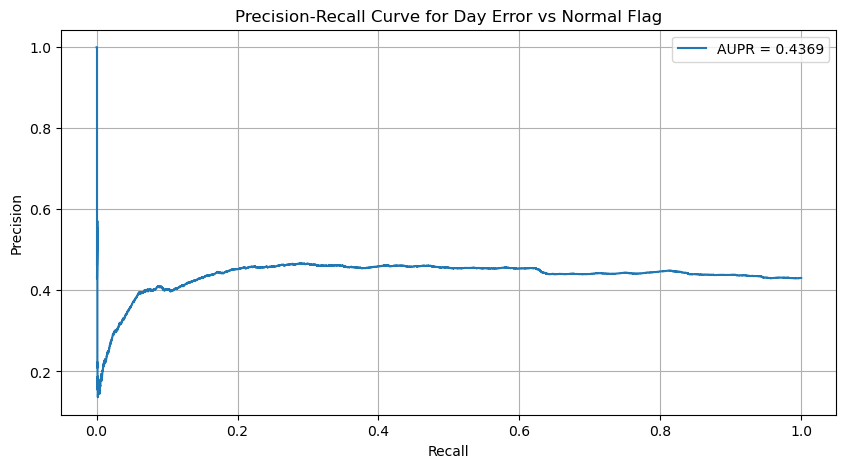

In [31]:
from sklearn.metrics import average_precision_score, precision_recall_curve
print(f"AUPR: {average_precision_score(dayNormal, dayErr.max(axis=2).mean(axis=1))}")

precision, recall, _ = precision_recall_curve(
    dayNormal, dayErr.max(axis=2).mean(axis=1)
)
plt.figure(figsize=(10, 5))
plt.plot(recall, precision, label=f"AUPR = {average_precision_score(dayNormal, dayErr.max(axis=2).mean(axis=1)):.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Day Error vs Normal Flag")
plt.legend()
plt.grid()
plt.show()

# End

In [32]:
for turbineData in turbineDatas:
    turbineData.close()